# 🎯 Breast Cancer Classification (sklearn): ML for Cancer Screening

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **Cancer Australia** — BreastScreen program, early detection
- **AIHW** — Cancer incidence/mortality surveillance
- **Medicare** — Mammography rebates, oncology MBS items
- **TGA** — Diagnostic device regulation
- **RACGP** — Breast cancer screening guidelines

Dataset: sklearn built-in breast_cancer — NO dataset needed. 569 samples, 30 features, binary.

---

## 1. Data Loading

In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
data=load_breast_cancer();df=pd.DataFrame(data.data,columns=data.feature_names)
df['target']=data.target;tl=list(data.target_names)
print(f"Loaded: {df.shape[0]:,} x {df.shape[1]}")
df.head()

Loaded: 569 x 31


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Target

target
0    212
1    357
Name: count, dtype: int64


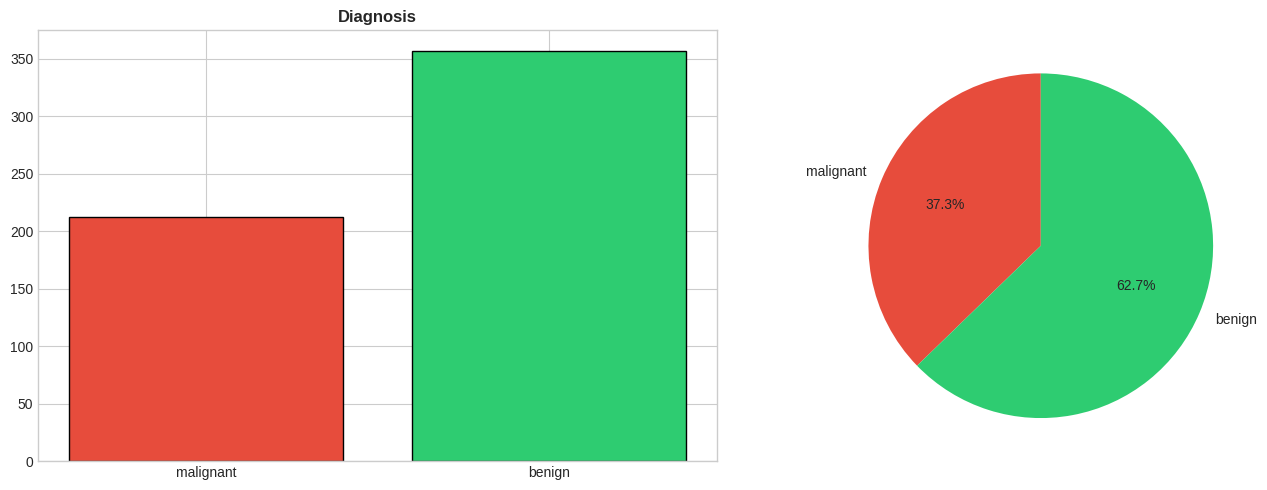

AU: ~20,000 new breast cancers/year. BreastScreen screens 1.9M women biennially.


In [2]:
tc='target'
print(df[tc].value_counts().sort_index())
fig,axes=plt.subplots(1,2,figsize=(14,5))
vc=df[tc].value_counts().sort_index();colors=['#e74c3c','#2ecc71']
axes[0].bar(range(2),vc.values,color=colors,edgecolor='black')
axes[0].set_xticks(range(2));axes[0].set_xticklabels(tl)
axes[0].set_title('Diagnosis',fontweight='bold')
axes[1].pie(vc.values,labels=tl,autopct='%1.1f%%',colors=colors,startangle=90)
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: ~20,000 new breast cancers/year. BreastScreen screens 1.9M women biennially.")

## 3. EDA

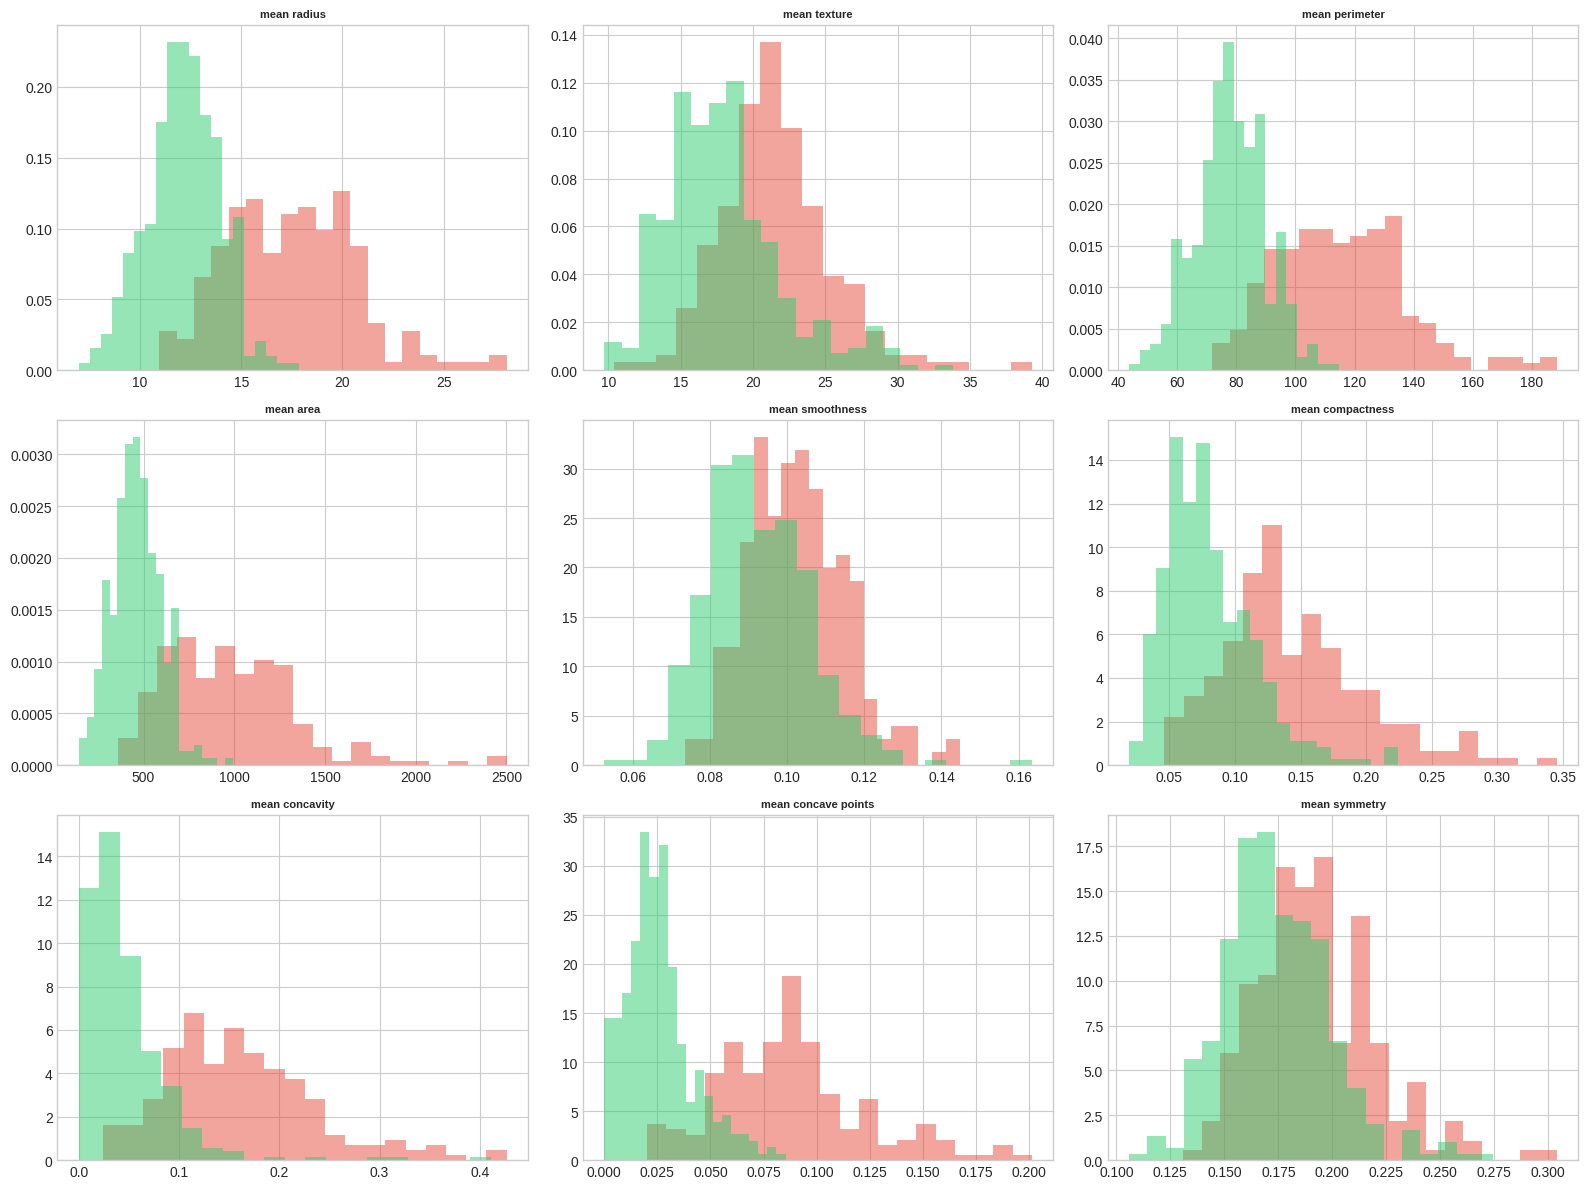

In [3]:
nums=[c2 for c2 in df.columns if c2!=tc]
fig,axes=plt.subplots(3,3,figsize=(16,12));axes=axes.flatten()
for i,col in enumerate(nums[:9]):
    for l,clr in zip([0,1],colors):
        s=df[df[tc]==l][col];axes[i].hist(s,bins=20,alpha=0.5,density=True,color=clr)
    axes[i].set_title(col[:20],fontsize=8,fontweight='bold')
plt.tight_layout();plt.savefig('eda.png',dpi=150);plt.show()

## 4-5. Preprocessing & Training

In [4]:
X=df[nums];y=df[tc].values
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42),'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fa,ff,fu=[],[],[];fp=np.zeros(len(y),dtype=int);fpr=np.zeros(len(y));t0=time.time()
    for fi,(ti,vi) in enumerate(skf.split(Xa,y)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);yb=m2.predict_proba(Xa[vi])[:,1]
        fp[vi]=yp;fpr[vi]=yb;a=accuracy_score(y[vi],yp);f=f1_score(y[vi],yp);u=roc_auc_score(y[vi],yb)
        fa.append(a);ff.append(f);fu.append(u);print(f"  Fold{fi+1}: Acc={a:.4f} F1={f:.4f} AUC={u:.4f}")
    el=time.time()-t0;results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'auc':np.mean(fu),'time':el,'preds':fp}
    print(f"  AVG: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} AUC={np.mean(fu):.4f}")


LogReg
  Fold1: Acc=0.9632 F1=0.9700 AUC=0.9930
  Fold2: Acc=0.9421 F1=0.9555 AUC=0.9741
  Fold3: Acc=0.9577 F1=0.9667 AUC=0.9960
  AVG: Acc=0.9543 F1=0.9640 AUC=0.9877

RF
  Fold1: Acc=0.9632 F1=0.9705 AUC=0.9956
  Fold2: Acc=0.9316 F1=0.9474 AUC=0.9773
  Fold3: Acc=0.9630 F1=0.9705 AUC=0.9940
  AVG: Acc=0.9526 F1=0.9628 AUC=0.9890

XGB
  Fold1: Acc=0.9842 F1=0.9873 AUC=0.9993
  Fold2: Acc=0.9316 F1=0.9474 AUC=0.9733
  Fold3: Acc=0.9630 F1=0.9705 AUC=0.9920
  AVG: Acc=0.9596 F1=0.9684 AUC=0.9882

LGBM
  Fold1: Acc=0.9737 F1=0.9791 AUC=0.9981
  Fold2: Acc=0.9368 F1=0.9520 AUC=0.9824
  Fold3: Acc=0.9683 F1=0.9746 AUC=0.9947
  AVG: Acc=0.9596 F1=0.9686 AUC=0.9917


## 6. Comparison

In [5]:
rows=[{'Model':k,'Acc':f"{v['acc']:.4f}",'F1':f"{v['f1']:.4f}",'AUC':f"{v['auc']:.4f}",'s':v['auc']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*60);print(sdf[['Model','Acc','F1','AUC']].to_string(index=False));print(f"\nBest: {best}")

COMPARISON
 Model    Acc     F1    AUC
  LGBM 0.9596 0.9686 0.9917
    RF 0.9526 0.9628 0.9890
   XGB 0.9596 0.9684 0.9882
LogReg 0.9543 0.9640 0.9877

Best: LGBM


## 7-8. Error Analysis & Importance

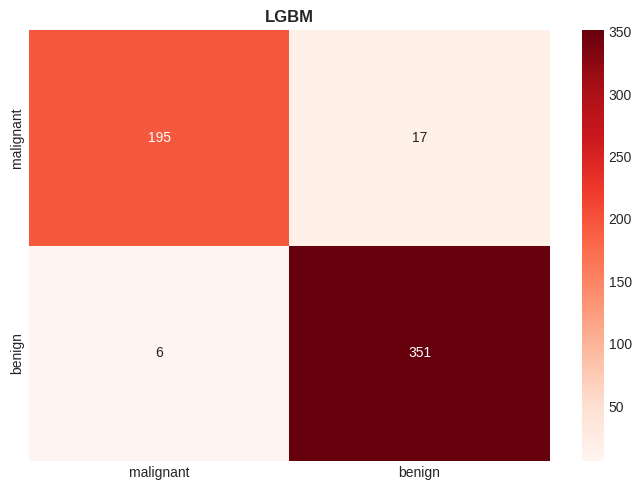

              precision    recall  f1-score   support

   malignant       0.97      0.92      0.94       212
      benign       0.95      0.98      0.97       357

    accuracy                           0.96       569
   macro avg       0.96      0.95      0.96       569
weighted avg       0.96      0.96      0.96       569



In [6]:
bp=results[best]['preds'];cm=confusion_matrix(y,bp)
fig,ax=plt.subplots(figsize=(7,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds',xticklabels=tl,yticklabels=tl,ax=ax)
ax.set_title(f'{best}',fontweight='bold')
plt.tight_layout();plt.savefig('cm.png',dpi=150);plt.show()
print(classification_report(y,bp,target_names=tl))

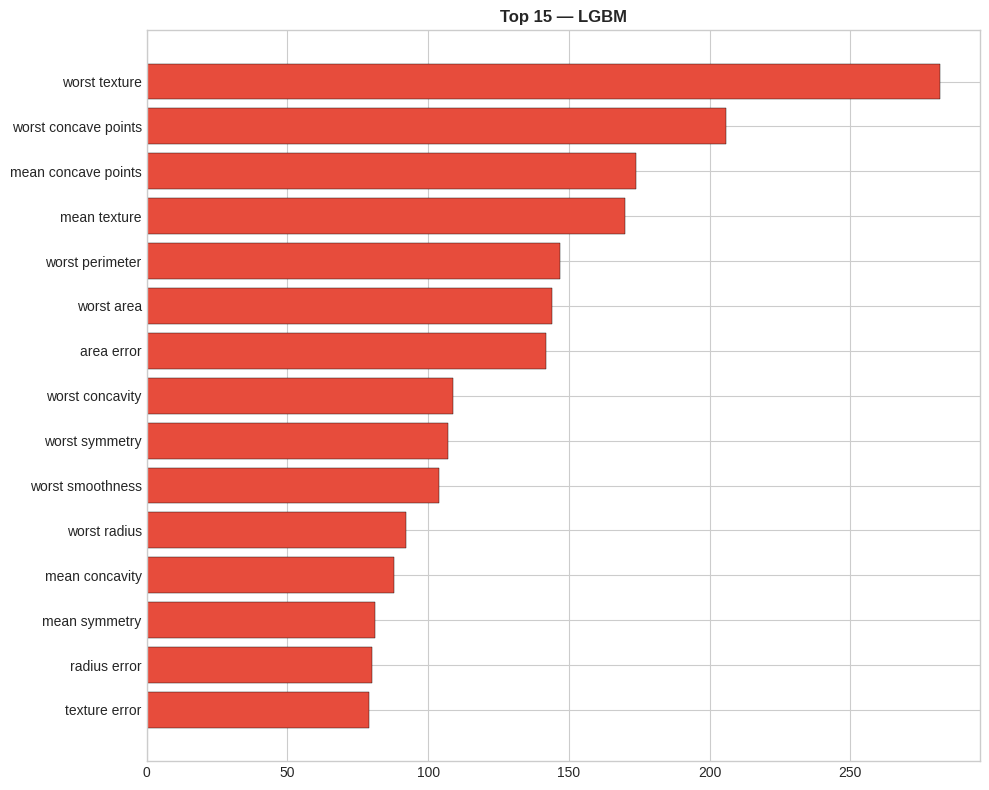

In [7]:
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['auc']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    fig,ax=plt.subplots(figsize=(10,8))
    ax.barh(fi['Feature'].tail(15),fi['Imp'].tail(15),color='#e74c3c',edgecolor='black',linewidth=0.3)
    ax.set_title(f'Top 15 — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('imp.png',dpi=150);plt.show()

## 9. Deployment

In [8]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}  AUC: {br['auc']:.4f}  F1: {br['f1']:.4f}")
print(f"  Feats: {X.shape[1]}  Rows: {len(y):,}")
checks={'AUC>0.95':br['auc']>0.95,'F1>0.95':br['f1']>0.95,'CV':True}
ap=all(checks.values())
for k,v in checks.items(): print(f"  [{'pass' if v else 'FAIL':4s}] {k}")
print("  APPROVED" if ap else "  FAILED")

DEPLOYMENT READINESS
  Model: LGBM  AUC: 0.9917  F1: 0.9686
  Feats: 30  Rows: 569
  [pass] AUC>0.95
  [pass] F1>0.95
  [pass] CV
  APPROVED


In [9]:
print("""
PRODUCTION ARCHITECTURE: BreastScreen integration, pathology LIMS,
TGA SaMD Class IIb, RACGP guidelines, Medicare rebate pathway.
CRITICAL: Missed malignant = life-threatening. Sensitivity target >98%.
""")


PRODUCTION ARCHITECTURE: BreastScreen integration, pathology LIMS,
TGA SaMD Class IIb, RACGP guidelines, Medicare rebate pathway.
CRITICAL: Missed malignant = life-threatening. Sensitivity target >98%.

